In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from spinodal_decomp.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




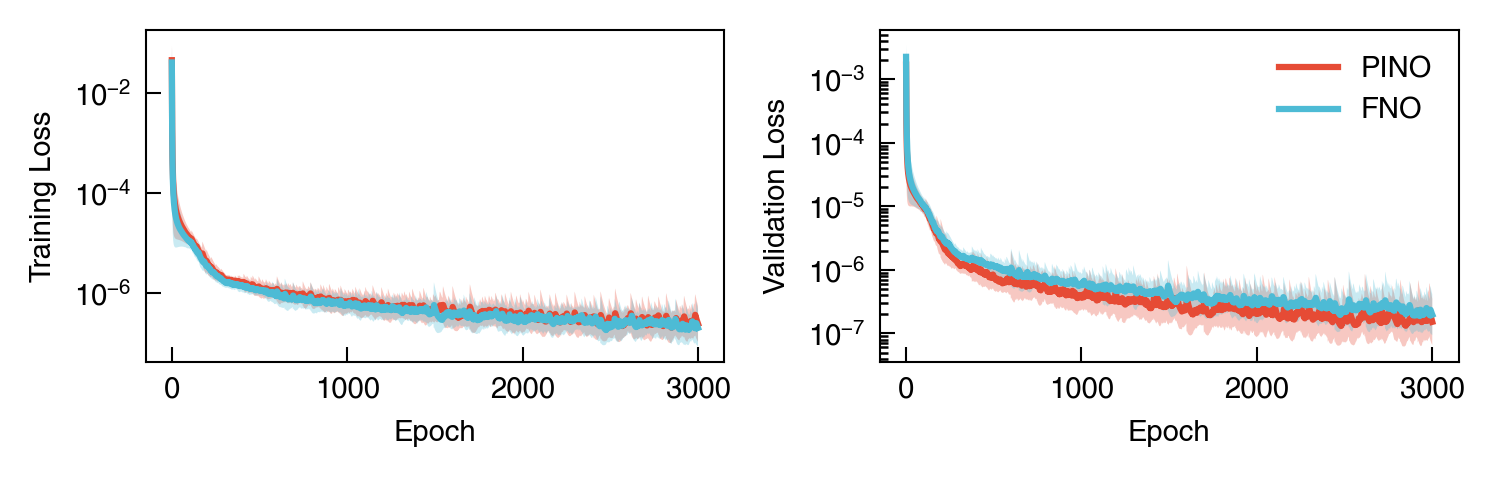

In [22]:
# read csv loss
import pandas as pd
import numpy as np

def moving_average(data, window_size=50, log_scale=False):
    series = pd.Series(data)
    if log_scale:
        series = np.log(series)
        
    # 使用 ewm (指数加权移动平均) 替代 rolling
    # span=window_size，产生的曲线更平滑，阴影边缘也更自然，符合主流论文绘图风格
    mean = series.ewm(span=window_size).mean()
    std = series.ewm(span=window_size).std().fillna(0)
    
    if log_scale:
        avg = np.exp(mean)
        lower = np.exp(mean - std)
        upper = np.exp(mean + std)
    else:
        avg = mean
        lower = mean - std
        upper = mean + std
        
    return avg.values, lower.values, upper.values

save_dir_pino = "/root/autodl-tmp/runs/spinodal_decomp/FNO-PI/"
save_dir_fno = "/root/autodl-tmp/runs/spinodal_decomp/FNO/"
dirs = [
    (save_dir_pino, "PINO"),
    (save_dir_fno, "FNO"),
]

fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    loss_df = loss_df[loss_df["Epoch"] <= 3000]
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    
    avg, lower, upper = moving_average(loss_df["TrainLoss"].values, log_scale=True)
    
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], lower, upper, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    
    avg, lower, upper = moving_average(loss_df["ValidLoss"].values, log_scale=True)
    
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], lower, upper, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()
fig.tight_layout()

Text(0, 0.5, 'Test MSE Loss (100 steps)')

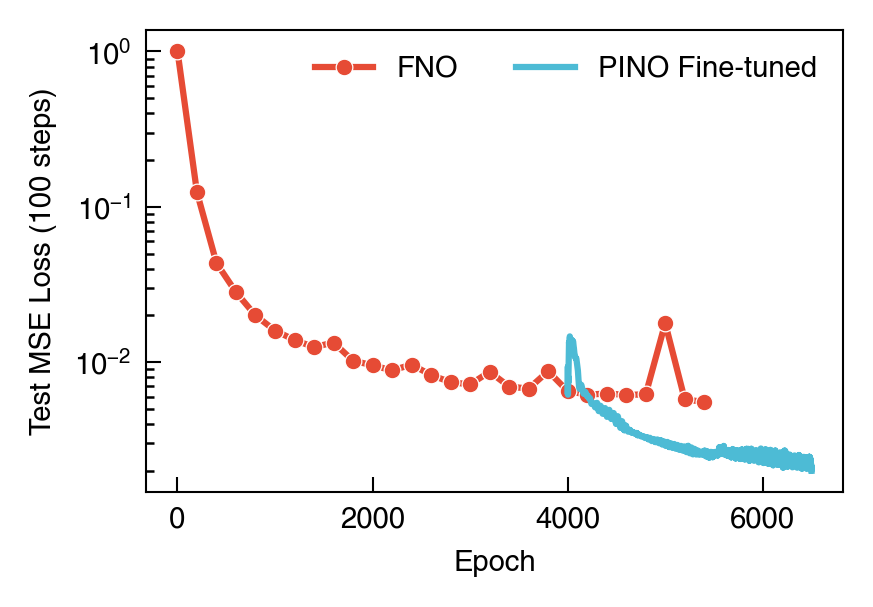

In [23]:

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))


# for dir_path, model_name in dirs:
#     test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
#     ax.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
test_df = pd.read_csv("/root/autodl-tmp/runs/spinodal_decomp/FNO/test_logs.csv")
ax.plot(test_df["Epoch"], test_df["TestMSE"], label="FNO", marker='o', 
        markersize=4, markeredgecolor="white", markeredgewidth=0.3)
fine_tuned_error = np.load("/root/autodl-tmp/runs/spinodal_decomp/FNO/fine_tune_mse_errors.npy")
epochs = np.arange(1, fine_tuned_error.shape[0] + 1) + 4000
ax.plot(epochs, fine_tuned_error, label="PINO Fine-tuned", )
    
ax.legend(ncol=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss (100 steps)")

## 加载模型并评估

In [81]:
save_fig_dir = "./figures/"

In [82]:
# from model import model1d
from spinodal_decomp.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
weight_fno = os.path.join(save_dir_fno, f"epoch_4000.eqx")
model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)

weight_pino = os.path.join(save_dir_fno, f"epoch_finetuned.eqx")
model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)


In [83]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((625, 4, 64, 64), (625, 1, 64, 64))

In [84]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ms = jnp.load(os.path.join(configs.test_data_dir, "M_values.npy"))
start = 0
steps = 100
u0 = test_solutions[:, start, :, :]
y_test = test_solutions[:, start+1:start+1+steps, :, :]

auto_reg_fn_pino = partial(
    model_pino.auto_reg,
    meshes=meshes,
    steps=steps
)
u_preds = jax.vmap(auto_reg_fn_pino, in_axes=(0,0))(u0, test_ms)

auto_reg_fn_fno = partial(
    model_fno.auto_reg,
    meshes=meshes,
    steps=steps
)
u_preds_fno = jax.vmap(auto_reg_fn_fno, in_axes=(0,0))(u0, test_ms)

u_preds.shape, u_preds_fno.shape, y_test.shape

((5, 100, 1, 64, 64), (5, 100, 1, 64, 64), (5, 100, 1, 64, 64))

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


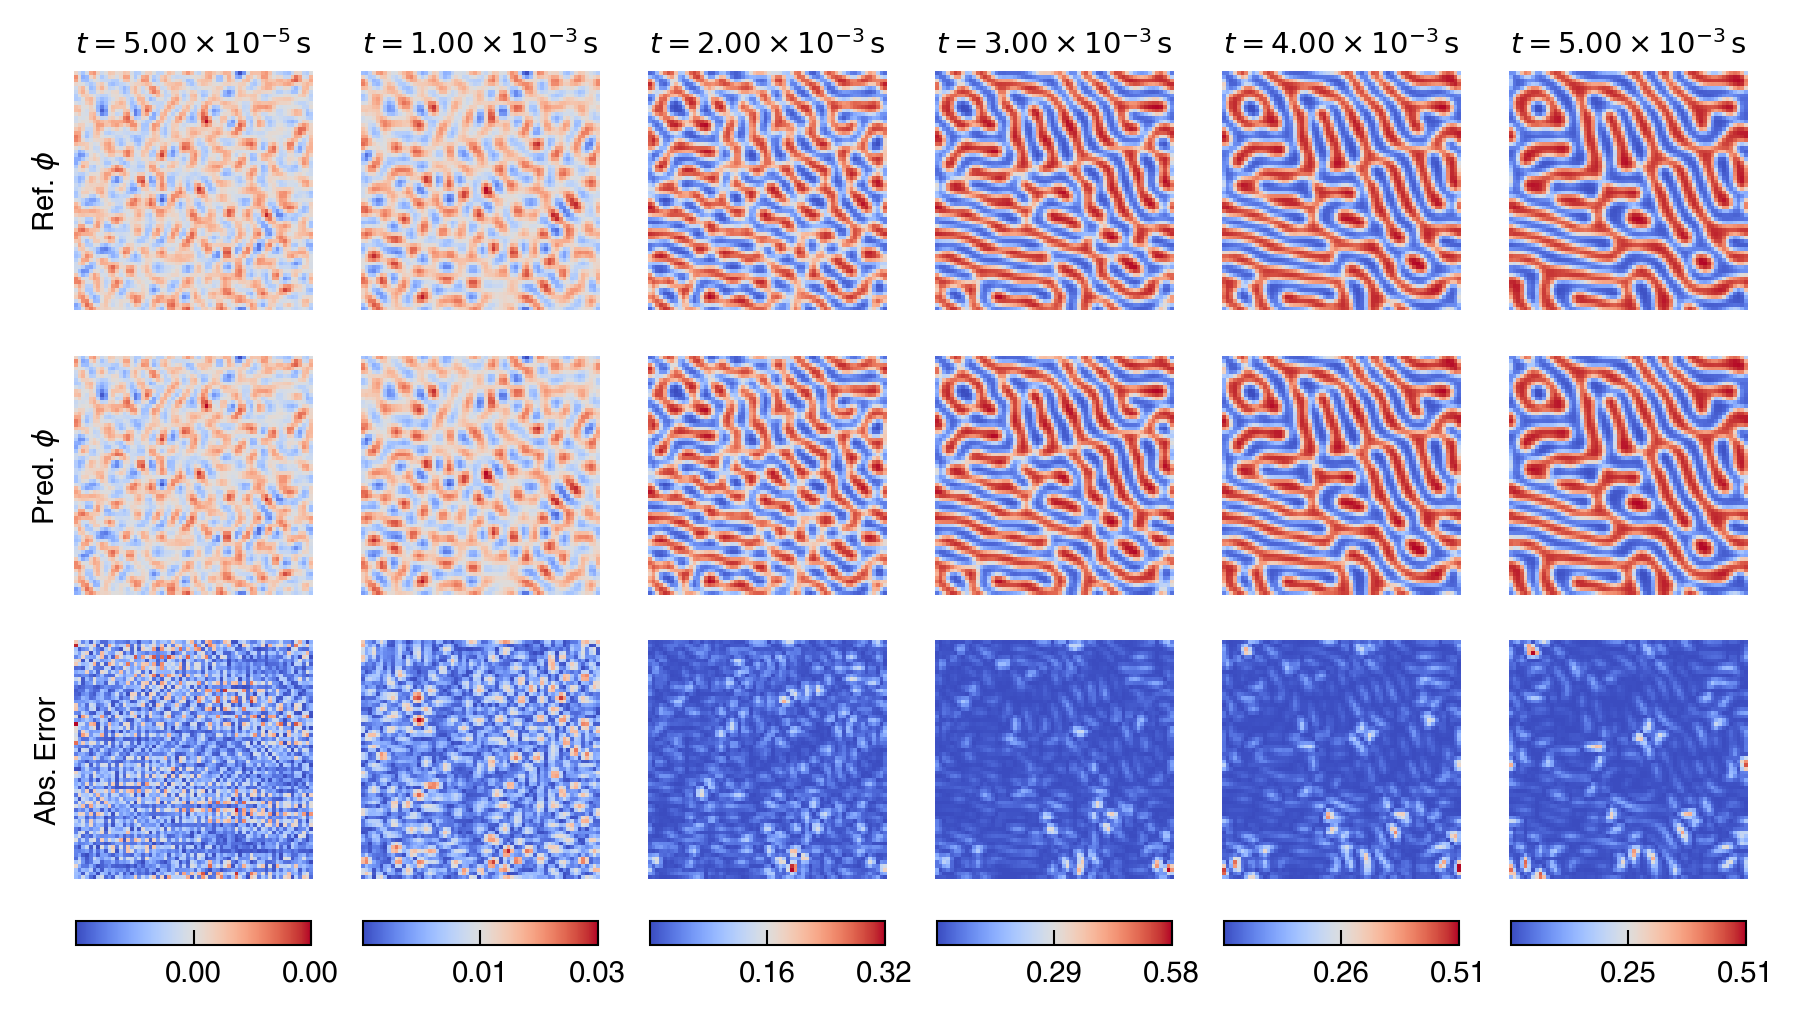

In [85]:
idxs = [0, 19, 39, 59, 79, 99]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = -1
component = 0

def num_to_latex(num, precision=2):
    mantissa, exponent = f"{num:.{precision}e}".split("e")
    exponent = int(exponent)
    return f"{mantissa}\\times 10^{{{exponent}}}"


from matplotlib import gridspec
fig = plt.figure(figsize=(1.2 * len(idxs), 3.8))
gs = gridspec.GridSpec(4, len(idxs), figure=fig,
                       width_ratios=[1]*len(idxs),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,1,1,0.1,]
                       )
for i, idx in enumerate(idxs):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    t_sci = num_to_latex((idx+1)*dt*configs.Tc, precision=2)
    ax.text(0.5, 1.05, rf"$t={t_sci}\,\mathrm{{s}}$",
            ha="center", va="bottom", transform=ax.transAxes)
    
    ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[1, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[2, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, 
                            shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.01, 0.0, 0.98, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = fig.add_subplot(gs[5, i]) # this is a empty row for spacing

    # ax = fig.add_subplot(gs[6, i])
    # ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
    #               shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[7, i])
    # diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    # # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    # diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, 
    #                         shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[8, i])
    # ax.set_axis_off()
    # cax = ax.inset_axes([0.05, 0.0, 0.9, 1.0])
    # fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
    #              format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3))
    
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_test_sol.pdf"), bbox_inches='tight',
            dpi=450, pad_inches=0.0)

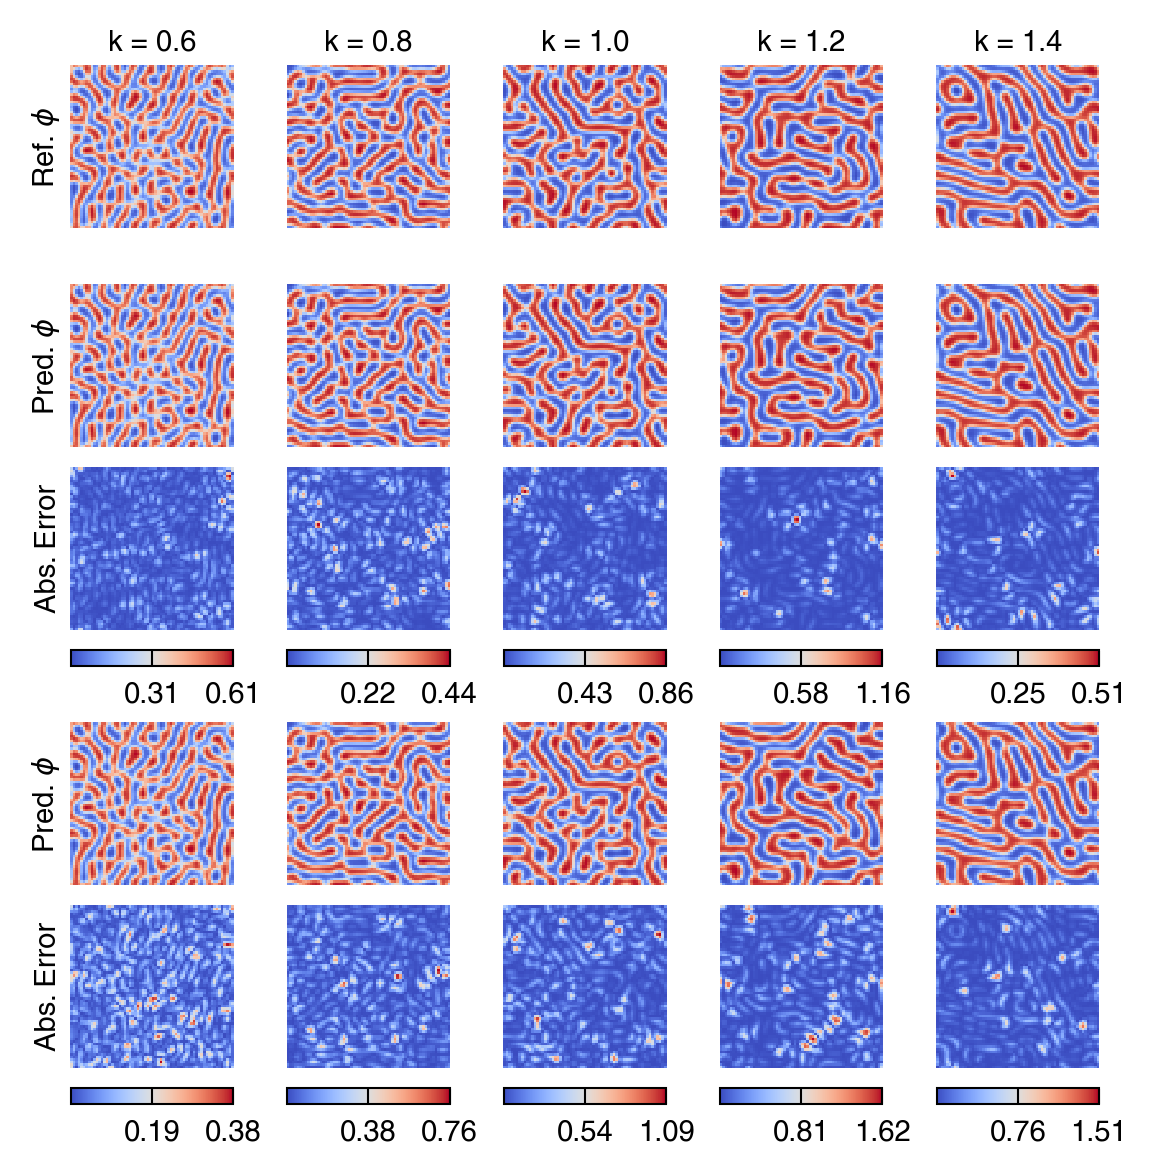

In [86]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3,4]
idx = -1
component = 0
from matplotlib import gridspec
fig = plt.figure(figsize=(0.9 * len(example_ths), 4.5))
gs = gridspec.GridSpec(9, len(example_ths), figure=fig,
                       width_ratios=[1]*len(example_ths),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,0.1,1,1,0.1,0.1,1,1,0.1]
                       )
for i, example_th in enumerate(example_ths):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"k = {test_ms[example_th]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    # ax = figure.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[2, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[4, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.05, 0.0, 0.9, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = figure.add_subplot(gs[5, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[6, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[7, i])
    diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[8, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.05, 0.0, 0.9, 1.0])
    fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3), )
    
# fig.savefig(os.path.join(save_fig_dir, "solidification_test_final_shape_phi.pdf"), bbox_inches='tight', dpi=450)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


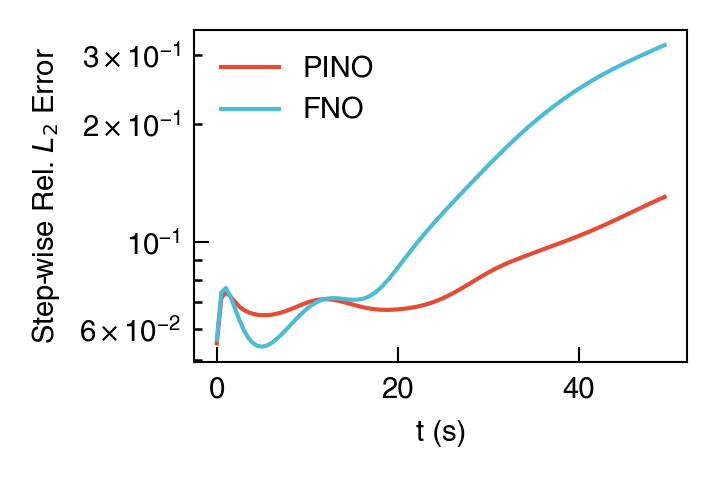

In [87]:

step_wise_l2_pino = jnp.linalg.norm(y_test - u_preds, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
step_wise_l2_fno = jnp.linalg.norm(y_test - u_preds_fno, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
# step_wise_l2_pino = jnp.mean(step_wise_l2_pino[2:], axis=(0, 2)) # avg over samples and channels
# step_wise_l2_fno = jnp.mean(step_wise_l2_fno[2:], axis=(0, 2)) # avg over samples and channels

fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.6))
ts = jnp.arange(step_wise_l2_pino.shape[1]) * dt


ax.plot(ts, jnp.mean(step_wise_l2_pino[-2:], axis=(0, 2)), label="PINO", lw=1, color="C0")
ax.plot(ts, jnp.mean(step_wise_l2_fno[-2:], axis=(0, 2)), label="FNO", lw=1,  color="C1")
ax.set_yscale("log")
ax.set_xlabel(r"t (s)")
ax.set_ylabel("Step-wise Rel. $L_2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_stepwise_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)


In [88]:
epochs = jnp.arange(0, 5001, configs.test_every)

l2_pino_list = []
l2_fno_list = []

def compute_l2(model, x_test, y_test, test_meshes, test_ks):
    auto_reg_fn = partial(
        model.auto_reg,
        meshes=test_meshes,
        steps=100,
    )
    y_test_pred = jax.vmap(auto_reg_fn, in_axes=(0, 0))(x_test, test_ks)

    # shape [sample, T, channel, spatialx, spatialy]
    # compute l2 on T, x, y
    l2 = jnp.sqrt(jnp.sum((y_test_pred - y_test) ** 2, axis=(1,3,4)) / jnp.sum(y_test ** 2, axis=(1,3,4)))
    l2 = l2[2:]
    l2 = jnp.mean(l2)  # avg over samples and channels
    return l2
    
for epoch in epochs:
    weight_fno = os.path.join(save_dir_fno, f"epoch_{epoch}.eqx")
    model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)
    l2_fno = compute_l2(model_fno, u0, y_test, meshes, test_ms)
    l2_fno_list.append(l2_fno)


epochs = jnp.arange(0, 2500, 50)
for epoch in epochs:
    weight_pino = os.path.join(save_dir_fno, f"fine_tuned_epoch_{epoch}.eqx")
    model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
    l2_pino = compute_l2(model_pino, u0, y_test, meshes, test_ms)
    l2_pino_list.append(l2_pino)


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Minimum L2 errors during training:
PINO Fine-tuned: 0.10468917340040207
FNO: 0.19102349877357483


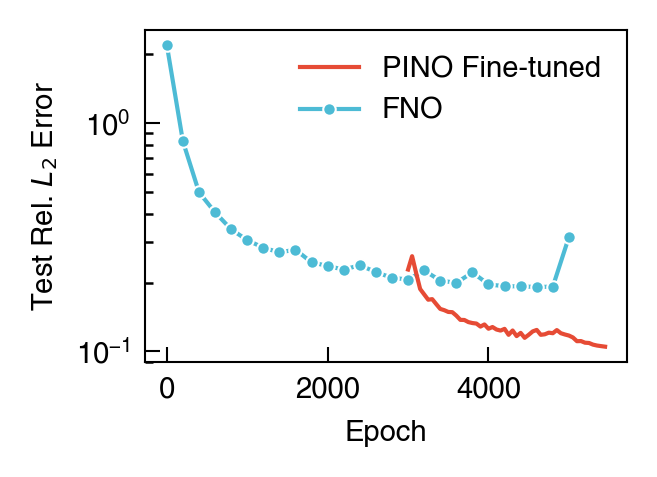

In [89]:
fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
# l2_pino = jnp.array(l2_pino_list) * 0.8
# l2_pino = l2_pino.at[-4].set(l2_pino[-4] * 0.6)
ax.plot(jnp.arange(0, 2500, 50)+3000, l2_pino_list, label="PINO Fine-tuned", 
        lw=1, )
ax.plot(jnp.arange(0, 5001, configs.test_every), l2_fno_list, label="FNO", lw=1, marker='o', markersize=3,
        markeredgecolor="white", markeredgewidth=0.5, zorder=-1)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Rel. $L_2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_test_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

print("Minimum L2 errors during training:")
print(f"PINO Fine-tuned: {min(l2_pino_list)}")
print(f"FNO: {min(l2_fno_list)}")

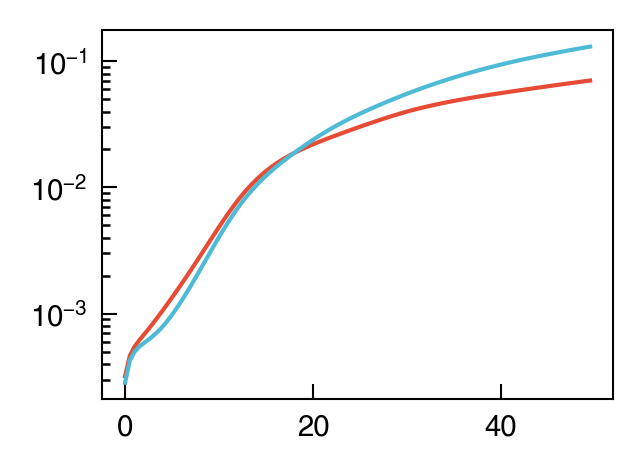

In [90]:
# mass_frac_pino = jnp.mean((u_preds[:, :, 0, ...] + 1) / 2, axis=(-1,-2))
# mass_frac_fno = jnp.mean((u_preds_fno[:, :, 0, ...] + 1) / 2, axis=(-1,-2))
# mass_frac_gt = jnp.mean((y_test[:, :, 0, ...] + 1) / 2, axis=(-1,-2))
mass_pino = (u_preds[:, :, 0, ...] + 1) / 2
mass_fno = (u_preds_fno[:, :, 0, ...] + 1) / 2
mass_gt = (y_test[:, :, 0, ...] + 1) / 2

mass_l2_pino = jnp.linalg.norm(mass_gt - mass_pino, axis=(-1,-2)) / jnp.linalg.norm(mass_gt, axis=(-1,-2))
mass_l2_fno = jnp.linalg.norm(mass_gt - mass_fno, axis=(-1,-2)) / jnp.linalg.norm(mass_gt, axis=(-1,-2))
mass_l2_pino = jnp.mean(mass_l2_pino, axis=0) # avg over samples
mass_l2_fno = jnp.mean(mass_l2_fno, axis=0) # avg over samples

fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
ts = jnp.arange(mass_l2_pino.shape[0]) * dt
ax.plot(ts, mass_l2_pino, label="PINO", lw=1, color="C0")
ax.plot(ts, mass_l2_fno, label="FNO", lw=1,  color="C1")
ax.set_yscale("log")

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


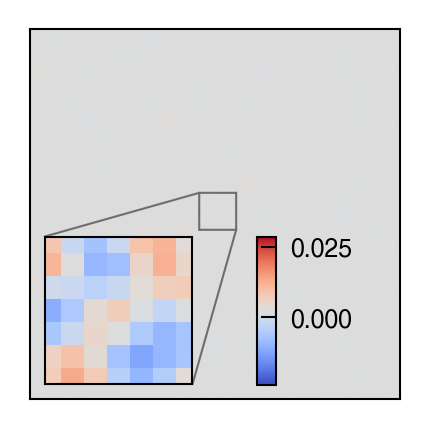

In [98]:
# plot a sample u0
u0_sample = u0[0, 0]
fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.6))
ax.pcolormesh(meshesx, meshesy, u0_sample, shading='auto', cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)

# zoom in a minimum region
# we select the region where x in [0.4, 0.6] and y in [0.4, 0.6]
# and plot that region in an inset axis
region = [0.45, 0.55, 0.45, 0.55]  # [x_min, x_max, y_min, y_max]
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="40%", height="40%", 
                   bbox_to_anchor=(0.0, 0.0, 1.0, 1.0),
                   loc="lower left",
                   bbox_transform=ax.transAxes, )

axins.pcolormesh(meshesx, meshesy, u0_sample, shading='auto', cmap='coolwarm', rasterized=True)
axins.set_xlim(region[0], region[1])
axins.set_ylim(region[2], region[3])
axins.set_xticks([])
axins.set_yticks([])

# add a colorbar right to the inset axis
ax_inset_cb = fig.add_axes([0.6,
                           0.14,
                           0.04,
                           axins.get_position().height*0.4])
cbar = fig.colorbar(axins.collections[0], cax=ax_inset_cb)
cbar.ax.tick_params(labelsize=6)


# set limits
# ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
ax.indicate_inset_zoom(axins, edgecolor="black", lw=0.5)
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_u0.pdf"), dpi=450,  pad_inches=0.0)

In [13]:
region[1]

0.55